# Cleaning Data

In [108]:
import pandas as pd
import numpy as np
import altair as alt
import missingno as mno

In [109]:
# loading data
df_houses = pd.read_csv("/Users/saidalkildani/Desktop/DS_AI/Projects/EDA_Project_SA/data/eda_houses.csv")

In [110]:
df_houses

,date,price,house_id,id,id.1,bedrooms,bathrooms,sqft_living,sqft_lot,floors,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.0,7129300520,1,7129300520,3.0,1.00,1180.0,5650.0,1.0,...,7,1180.0,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0
1,2014-12-09,538000.0,6414100192,2,6414100192,3.0,2.25,2570.0,7242.0,2.0,...,7,2170.0,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0
2,2015-02-25,180000.0,5631500400,3,5631500400,2.0,1.00,770.0,10000.0,1.0,...,6,770.0,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0
3,2014-12-09,604000.0,2487200875,4,2487200875,4.0,3.00,1960.0,5000.0,1.0,...,7,1050.0,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0
4,2015-02-18,510000.0,1954400510,5,1954400510,3.0,2.00,1680.0,8080.0,1.0,...,8,1680.0,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,2014-05-21,360000.0,263000018,21593,263000018,3.0,2.50,1530.0,1131.0,3.0,...,8,1530.0,0.0,2009,0.0,98103,47.6993,-122.346,1530.0,1509.0
21593,2015-02-23,400000.0,6600060120,21594,6600060120,4.0,2.50,2310.0,5813.0,2.0,...,8,2310.0,0.0,2014,0.0,98146,47.5107,-122.362,1830.0,7200.0
21594,2014-06-23,402101.0,1523300141,21595,1523300141,2.0,0.75,1020.0,1350.0,2.0,...,7,1020.0,0.0,2009,0.0,98144,47.5944,-122.299,1020.0,2007.0
21595,2015-01-16,400000.0,291310100,21596,291310100,3.0,2.50,1600.0,2388.0,2.0,...,8,1600.0,0.0,2004,0.0,98027,47.5345,-122.069,1410.0,1287.0


## Columns and Data Types

In [111]:
# Removing duplicate columns
df_houses.drop('id.1', axis=1, inplace=True)
df_houses.columns

Index(['date', 'price', 'house_id', 'id', 'bedrooms', 'bathrooms',
       'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
       'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [112]:
# Check data type, is type that needs to be converted?
df_houses.dtypes
## waterfront, view, condition, and grade are categorical variables. 

df_houses['waterfront'] = df_houses['waterfront'].astype('category')
df_houses['view'] = df_houses['view'].astype('category')
df_houses['condition'] = df_houses['condition'].astype('category')
df_houses['grade'] = df_houses['grade'].astype('category')
## date should be set to date type yy-mm-dd
df_houses['date'] = pd.to_datetime(df_houses['date'], format='%Y-%m-%d')
## year renovated should be set to int
### entry needs to divided by 10
df_houses['yr_renovated'] = df_houses['yr_renovated'].astype('Int64')
df_houses.dtypes

date             datetime64[ns]
price                   float64
house_id                  int64
id                        int64
bedrooms                float64
bathrooms               float64
sqft_living             float64
sqft_lot                float64
floors                  float64
waterfront             category
view                   category
condition              category
grade                  category
sqft_above              float64
sqft_basement           float64
yr_built                  int64
yr_renovated              Int64
zipcode                   int64
lat                     float64
long                    float64
sqft_living15           float64
sqft_lot15              float64
dtype: object

## Missing values

In [113]:
# Check for missing values
df_houses.isnull().sum()
## Waterfront, view, sqft_basement, yr_renovated have missing values


date                0
price               0
house_id            0
id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
dtype: int64

<Axes: >

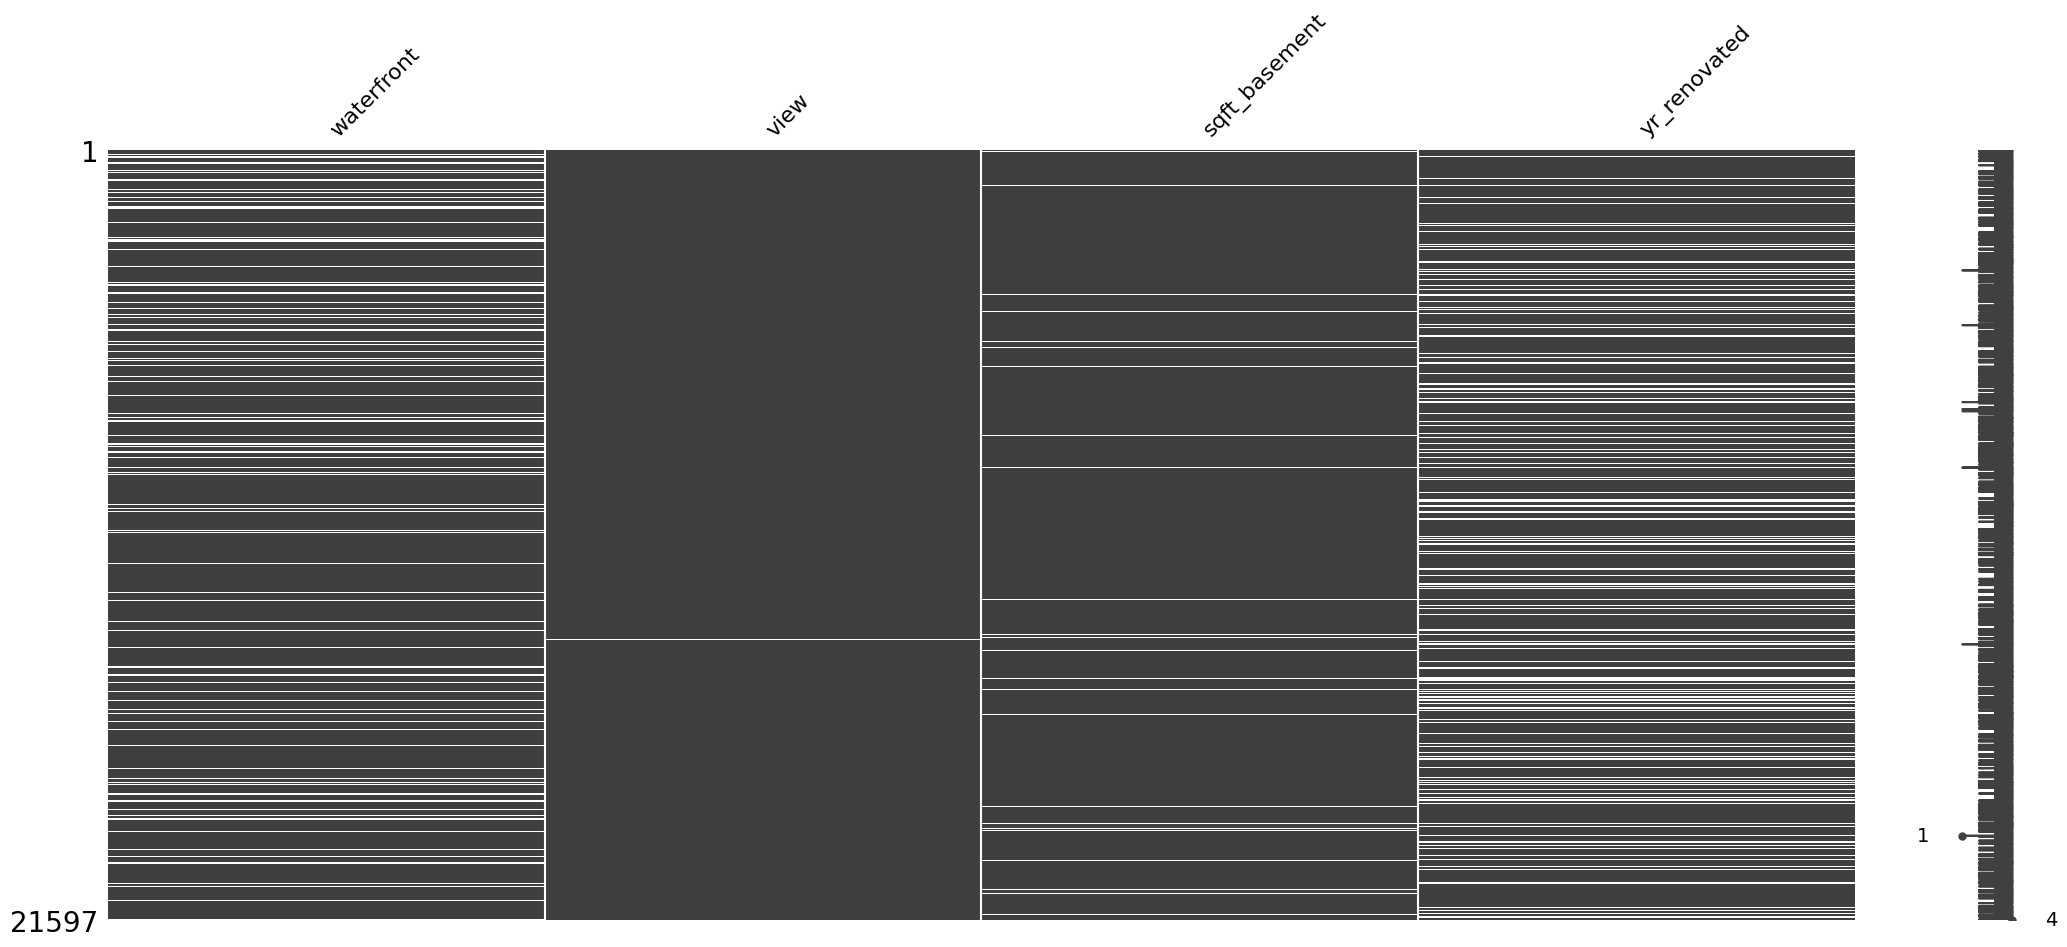

In [114]:
# No obvious patterns in the missing values
mno.matrix(df_houses[['waterfront', 'view', 'sqft_basement', 'yr_renovated']])

In [115]:
# Waterfront increases view score before removing missing values
waterfront_df = df_houses[df_houses['waterfront'] == 1]
chart = alt.Chart(waterfront_df).mark_bar().encode(
    x=alt.X('view:N', title='View Score'),  # 'O' for ordinal
    y=alt.Y('count()', title='Count'),
    tooltip=['view', 'count()']
).properties(
    title='Distribution of View Scores for Waterfront Properties',
    width=400
)

chart

alt.Chart(...)

In [116]:
## Waterfront NA will be set to zero (assuming missing values reflect no waterfront)
df_houses['waterfront'].fillna(0, inplace=True)
## If the house has missing view values but is on a waterfront, it will be set to 4. Otherwise, it'll be set to 0
df_houses['view'].where(df_houses['waterfront'] == 0, df_houses['view'].fillna(4, inplace=True))
## Setting sqft_basement to 0 if missing
df_houses['sqft_basement'].fillna(0, inplace=True) #if missing, we will assume there is no basement
## yr_renovated will be set to 0 if missing
df_houses['yr_renovated'].fillna(0, inplace=True) #if missing, we will assume the house has not been renovated

/var/folders/66/d9v27f_x2bs46pg0pkl_50d80000gn/T/ipykernel_81708/1241897043.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_houses['waterfront'].fillna(0, inplace=True)
/var/folders/66/d9v27f_x2bs46pg0pkl_50d80000gn/T/ipykernel_81708/1241897043.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

In [117]:
# Waterfront increases view score after removing missing values
waterfront_df = df_houses[df_houses['waterfront'] == 1]
chart = alt.Chart(waterfront_df).mark_bar().encode(
    x=alt.X('view:N', title='View Score'),  # 'O' for ordinal
    y=alt.Y('count()', title='Count'),
    tooltip=['view', 'count()']
).properties(
    title='Distribution of View Scores for Waterfront Properties',
    width=400
)

chart

alt.Chart(...)

## Modifying Data

In [118]:
# Modify entries to sensible values
# Values of yr_renovated need to be divided by 10
df_houses['yr_renovated'] = df_houses['yr_renovated'].apply(lambda x: x/10)
# Changing 0s to no and 1s to yes
df_houses['waterfront'] = df_houses['waterfront'].replace({1: 'yes', 0: 'no'})
# Adding a column for price per sqft
df_houses['price_per_sqft'] = (df_houses['price']/df_houses['sqft_lot'] + df_houses['sqft_living']).round(1)
# Adding a column for months
df_houses['month'] = df_houses['date'].dt.month
# Adding a seasons column according to months
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'fall'
df_houses['season'] = df_houses['month'].apply(get_season)
# Adding a column that indcates if house is renovated or not
df_houses['renovated?'] = df_houses['yr_renovated'].apply(lambda x: 'Yes' if x > 0 else 'No')
# Adding neighborhood column
df_houses['neighborhood'] = pd.factorize(df_houses['zipcode'])[0] + 1
# Adjusting the value of 33 to 3 in number of bedrooms
df_houses['bedrooms'].replace(33, 3, inplace=True)
# Add column of houses built before 2000 and renovated, we will call these houses like_new
df_houses['state'] = np.where(
    (df_houses['yr_renovated'] > 0) & (df_houses['yr_built'] < 2000),
    "like_new",  # Houses that are renovated and built before 2000
    np.where(
        df_houses['yr_built'] > 2010, 
        "new",  # Houses built after 2010
        "old"   # Houses built before 2010 and not renovated
    )
)


/var/folders/66/d9v27f_x2bs46pg0pkl_50d80000gn/T/ipykernel_81708/2439956760.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_houses['waterfront'] = df_houses['waterfront'].replace({1: 'yes', 0: 'no'})
/var/folders/66/d9v27f_x2bs46pg0pkl_50d80000gn/T/ipykernel_81708/2439956760.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the or

## Checking for Duplicates

In [119]:
# There are no duplicates in the data
df_houses[df_houses.duplicated()]

,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,lat,long,sqft_living15,sqft_lot15,price_per_sqft,month,season,renovated?,neighborhood,state


## Saving the Clean Data

In [120]:
# Export the clean data to a csv-file
df_houses.to_csv('data/eda_houses_clean.csv',index=False)